In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
from IPython.display import display
import plotly.express as px

# path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
path_local = "/home/scodo/.cache/kagglehub/datasets/sulianova/cardiovascular-disease-dataset/versions/1/cardio_train.csv"
data = pd.read_csv(path_local, sep=";")
display(data)



\\wsl.localhost\kali-linux\home\scodo\classification_initiation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
print("\n### Valeurs manquantes ###")
missing_values = data.isnull().sum()

if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
    print(f"\nNombre total de lignes avec valeurs manquantes: {data.isnull().any(axis=1).sum()}")

    # Supprimer les lignes avec valeurs manquantes
    data = data.dropna()
    print(f" Lignes avec NaN supprimées. Nouvelle taille: {data.shape}")
else:
    print("Aucune valeur manquante détectée ✓")



### Valeurs manquantes ###
Aucune valeur manquante détectée ✓


In [5]:
# Doublons
print("\n### 3.2 Doublons ###")
duplicates = data.duplicated().sum()
print(f"Nombre de lignes dupliquées: {duplicates}")
if duplicates > 0:
    data = data.drop_duplicates(ignore_index=True)
    print(f"✓ Doublons supprimés. Nouvelle taille: {data.shape}")


### 3.2 Doublons ###
Nombre de lignes dupliquées: 0


In [6]:
# Suppression des colonnes inutiles (IDs)
print("\n### Suppression des colonnes inutiles ###")
columns_to_drop = ['id']

existing_cols_to_drop = [col for col in columns_to_drop if col in data.columns]
print(f"Colonnes à supprimer: {existing_cols_to_drop}")

data = data.drop(columns=existing_cols_to_drop)
print(f"✓ Colonnes supprimées. Nouvelle taille: {data.shape}")



### Suppression des colonnes inutiles ###
Colonnes à supprimer: ['id']
✓ Colonnes supprimées. Nouvelle taille: (70000, 12)


In [7]:
# Statistiques descriptives
print("\n###  Statistiques descriptives ###")
display(data.describe())


###  Statistiques descriptives ###


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
TARGET ='cardio'
QUALITATIVE_VARIABLES = [
    'gender','gluc','smoke','alco','active','cholesterol'
]
QUANTITATIVE_VARIABLES = [col for col in data.columns if col not in QUALITATIVE_VARIABLES + [TARGET]]
QUALITATIVE_VARIABLES = [f for f in QUALITATIVE_VARIABLES if f in data.columns]
data_cat = data[QUALITATIVE_VARIABLES].copy()
data_num = data[QUANTITATIVE_VARIABLES].copy()
data_num


,age,height,weight,ap_hi,ap_lo
0,18393,168,62.0,110,80
1,20228,156,85.0,140,90
2,18857,165,64.0,130,70
3,17623,169,82.0,150,100
4,17474,156,56.0,100,60
...,...,...,...,...,...
69995,19240,168,76.0,120,80
69996,22601,158,126.0,140,90
69997,19066,183,105.0,180,90
69998,22431,163,72.0,135,80


In [ ]:
print("="*60)
print("DÉTECTION DES OUTLIERS")
print("="*60)

# Utiliser la méthode IQR (Interquartile Range)
numeric_cols = data_num.select_dtypes(include=[np.number]).columns

outliers_dict = {}
for col in numeric_cols:
    Q1 = data_num[col].quantile(0.25)
    Q3 = data_num[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_num[(data[col] < lower_bound) | (data[col] > upper_bound)]
    if len(outliers) > 0:
        outliers_dict[col] = len(outliers)

print("\nNombre d'outliers par colonne:")
if outliers_dict:
    for col, count in sorted(outliers_dict.items(), key=lambda x: x[1], reverse=True):
        print(f"  {col}: {count}")
else:
    print("  Aucun outlier détecté (en utilisant la méthode IQR)")


ÉTAPE 4: DÉTECTION DES OUTLIERS

Nombre d'outliers par colonne:
  ap_lo: 4632
  weight: 1819
  ap_hi: 1435
  height: 519
  age: 4


In [ ]:
# === VÉRIFICATION DES VALEURS HORS ÉCHELLE ===
print("="*60)
print("DÉTECTION DES VALEURS HORS ÉCHELLE")
print("="*60)

print("""
### OBJECTIF ###
Vérifier si certaines valeurs dépassent les limites attendues pour les features.
Contrairement aux outliers statistiques (IQR), ici on vérifie les limites physiques/logiques.
""")
expected_ranges= {
    'age': (0, 120*365),  # Âge humain plausible
    'height': (50, 250),  # Taille en cm plausible
    'weight': (3, 500),  # Poids en kg plausible
    'ap_hi': (80, 200),  # Pression systolique plausible
    'ap_lo': (60, 120)   # Pression diastolique plausible
}

ÉTAPE 8C: DÉTECTION DES VALEURS HORS ÉCHELLE

### OBJECTIF ###
Vérifier si certaines valeurs dépassent les limites attendues pour les features.
Contrairement aux outliers statistiques (IQR), ici on vérifie les limites physiques/logiques.



In [11]:
def pression_plausible(sys, dia):

    if sys <= dia:
        return False

    diff = sys - dia

    if diff < 20 or diff > 80:
        return False

    ratio = sys / dia

    if ratio < 1.2 or ratio > 1.8:
        return False

    return True

#ajouter une colonne indiquant si la pression est plausible ou non
data['pression_plausible'] = data.apply(lambda row: pression_plausible(row['ap_hi'], row['ap_lo']), axis=1)
data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,pression_plausible
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,True
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,True
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,False
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,True
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0,True
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1,True
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1,False
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1,True


In [12]:
#fonction donnant uniquement les indices des lignes avec des valeurs hors échelle et pression plausible
def detecter_valeurs_hors_echelle(data, expected_ranges):
    indices_hors_echelle = set()

    for col, (min_val, max_val) in expected_ranges.items():
        if col in data.columns:
            hors_echelle = data[(data[col] < min_val) | (data[col] > max_val)].index
            indices_hors_echelle.update(hors_echelle)

    # Vérification de la pression artérielle
    if 'ap_hi' in data.columns and 'ap_lo' in data.columns:
        for idx, row in data.iterrows():
            if not pression_plausible(row['ap_hi'], row['ap_lo']):
                indices_hors_echelle.add(idx)

    return sorted(indices_hors_echelle)

indices_hors_echelle = detecter_valeurs_hors_echelle(data, expected_ranges)
data_hors_echelle = data.loc[indices_hors_echelle]
data_hors_echelle


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,pression_plausible
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,False
9,19834,1,164,68.0,110,60,1,1,0,0,0,0,False
16,21296,1,170,75.0,130,70,1,1,0,0,0,0,False
23,23376,2,156,45.0,110,60,1,1,0,0,1,0,False
29,21057,2,169,74.0,130,70,1,3,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69959,19069,1,163,64.0,130,70,1,1,0,0,1,1,False
69967,21416,2,168,63.0,140,1000,1,1,0,0,1,1,False
69992,18792,1,161,56.0,170,90,1,1,0,0,1,1,False
69994,21074,1,165,80.0,150,80,1,1,0,0,1,1,False


In [13]:
# Remplacer ap_hi et ap_lo par les moyennes pour les lignes où pression_plausible est False

# Identifier les lignes avec pression implausible
pression_implausible_mask = ~data['pression_plausible']
nb_lignes_implausible = pression_implausible_mask.sum()

print(f"\nNombre de lignes avec pression implausible: {nb_lignes_implausible}")

if nb_lignes_implausible > 0:
    # Calculer les moyennes
    mean_ap_hi = data[data['pression_plausible']]['ap_hi'].mean()
    mean_ap_lo = data[data['pression_plausible']]['ap_lo'].mean()
    
    print(f"Moyenne de ap_hi (parmi les valeurs plausibles): {mean_ap_hi:.2f}")
    print(f"Moyenne de ap_lo (parmi les valeurs plausibles): {mean_ap_lo:.2f}")
    
    # Arrondir les moyennes pour les assigner aux colonnes int64
    mean_ap_hi_rounded = int(round(mean_ap_hi))
    mean_ap_lo_rounded = int(round(mean_ap_lo))
    
    print(f"Valeurs arrondies: ap_hi={mean_ap_hi_rounded}, ap_lo={mean_ap_lo_rounded}")
    
    # Remplacer les valeurs
    data.loc[pression_implausible_mask, 'ap_hi'] = mean_ap_hi_rounded
    data.loc[pression_implausible_mask, 'ap_lo'] = mean_ap_lo_rounded
    
    print(f"\n✓ {nb_lignes_implausible} lignes ont été corrigées")
    print("\nAperçu des lignes corrigées:")
    display(data[pression_implausible_mask][['age', 'ap_hi', 'ap_lo', 'pression_plausible']].head())
else:
    print("Aucune ligne avec pression implausible à corriger")


Nombre de lignes avec pression implausible: 5416
Moyenne de ap_hi (parmi les valeurs plausibles): 125.67
Moyenne de ap_lo (parmi les valeurs plausibles): 81.78
Valeurs arrondies: ap_hi=126, ap_lo=82

✓ 5416 lignes ont été corrigées

Aperçu des lignes corrigées:


,age,ap_hi,ap_lo,pression_plausible
2,18857,126,82,False
9,19834,126,82,False
16,21296,126,82,False
23,23376,126,82,False
29,21057,126,82,False


In [ ]:
print("="*60)
print(" FEATURE ENGINEERING - INDICE DE MASSE CORPOREL (IMC)")
print("="*60)

# Calculer l'IMC: poids (kg) / (hauteur (m)^2)
# L'hauteur est actuellement en cm, donc on la divise par 100
data['imc'] = data['weight'] / ((data['height'] / 100) ** 2)

print(f"\nStatistiques de l'IMC:")
print(f"  Minimum: {data['imc'].min():.2f}")
print(f"  Maximum: {data['imc'].max():.2f}")
print(f"  Moyenne: {data['imc'].mean():.2f}")
print(f"  Médiane: {data['imc'].median():.2f}")
print(f"  Écart-type: {data['imc'].std():.2f}")


print(f"\nAperçu des données avec l'IMC:")
display(data[['age', 'weight', 'height', 'imc']].head(10))

ÉTAPE 8.5: FEATURE ENGINEERING - INDICE DE MASSE CORPOREL (IMC)

Statistiques de l'IMC:
  Minimum: 3.47
  Maximum: 298.67
  Moyenne: 27.56
  Médiane: 26.37
  Écart-type: 6.09

Aperçu des données avec l'IMC:


,age,weight,height,imc
0,18393,62.0,168,21.967120
1,20228,85.0,156,34.927679
2,18857,64.0,165,23.507805
3,17623,82.0,169,28.710479
4,17474,56.0,156,23.011177
5,21914,67.0,151,29.384676
6,22113,93.0,157,37.729725
7,22584,95.0,178,29.983588
8,17668,71.0,158,28.440955
9,19834,68.0,164,25.282570


In [ ]:
# Préparer les données pour la modélisation
print("="*60)
print(" PRÉPARATION POUR LA MODÉLISATION")
print("="*60)

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
import warnings
warnings.filterwarnings('ignore')


ÉTAPE 9: PRÉPARATION POUR LA MODÉLISATION


In [ ]:
print("="*60)
print(" FEATURE ENGINEERING ")
print("="*60)

# Pulse Pressure (Pression pulsée) - différence entre systolique et diastolique
data['pulse_pressure'] = data['ap_hi'] - data['ap_lo']

# Tension Ratio (Ratio de pression)
data['tension_ratio'] = data['ap_hi'] / data['ap_lo']

# AGE-PRESSURE INTERACTION
data['age_ap_hi_interaction'] = data['age'] * data['ap_hi'] / 100

# IMC-Age Interaction
data['imc_age_interaction'] = data['imc'] * data['age'] / 100

# Weight-Age Ratio
data['weight_age_ratio'] = data['weight'] / (data['age'] / 10)

# Cardio Risk Score (combinaison des factors)
# Normaliser les features principales pour créer un score
from sklearn.preprocessing import MinMaxScaler
scaler_risk = MinMaxScaler()
risk_features = ['ap_hi', 'cholesterol', 'age', 'imc']
data_risk = data[risk_features].copy()
data_risk_scaled = scaler_risk.fit_transform(data_risk)
data['cardio_risk_score'] = data_risk_scaled.mean(axis=1)

# Catégories d'Hypertension (Standards OMS)
# Tension normale: syst < 120 et diast < 80
data['hypertension_stage'] = 0
data.loc[(data['ap_hi'] >= 130) | (data['ap_lo'] >= 80), 'hypertension_stage'] = 1
data.loc[(data['ap_hi'] >= 140) | (data['ap_lo'] >= 90), 'hypertension_stage'] = 2
print(f"  Distribution: {dict(data['hypertension_stage'].value_counts().sort_index())}")

# Indicateur de Risque Combiné (Âge + Cholestérol)
# Le risque explose si on est âgé ET qu'on a du cholestérol
data['high_risk_profile'] = ((data['age'] > 55*365) & (data['cholesterol'] > 1)).astype(int)

# Normalisation de la taille (Z-score par genre)
# La taille moyenne diffère par genre, l'écart à la moyenne est plus informatif
data['height_deviation'] = data.groupby('gender')['height'].transform(lambda x: (x - x.mean()) / x.std())

print(f" Shape des données: {data.shape}")


 FEATURE ENGINEERING 
  Distribution: {0: np.int64(11661), 1: np.int64(37123), 2: np.int64(21216)}
 Shape des données: (70000, 23)


In [ ]:
# Afficher les statistiques des nouvelles features
print("\n Statistiques des nouvelles features:")
new_features = ['pulse_pressure', 'tension_ratio', 'age_ap_hi_interaction', 
                'imc_age_interaction', 'weight_age_ratio', 'cardio_risk_score',
                'hypertension_stage', 'high_risk_profile', 'height_deviation']
print(data[new_features].describe())

# Vérifier la corrélation des nouvelles features avec la cible
print("\n Corrélation avec la cible (cardio):")
new_correlations = data[new_features + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print(new_correlations)

print("\n" + "="*60)


 Statistiques des nouvelles features:

 Corrélation avec la cible (cardio):
age_ap_hi_interaction    0.408976
hypertension_stage       0.375285
cardio_risk_score        0.359539
pulse_pressure           0.338735
imc_age_interaction      0.249028
high_risk_profile        0.182808
tension_ratio            0.171076
weight_age_ratio         0.020156
height_deviation         0.017458
Name: cardio, dtype: float64



In [18]:
print("="*60)
print("MISE À JOUR DES FEATURES (X avec nouvelles colonnes)")
print("="*60)

# Redéfinir X pour inclure les nouvelles features
# EN ENLEVANT: weight, height, ap_hi, ap_lo (remplacés par leurs dérivés)
X = data.drop(columns=[TARGET, 'pression_plausible', 'weight', 'height', 'ap_hi', 'ap_lo'])
y = data[TARGET]

print(f"\nShape des données:")
print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"\nDistribution de la cible:")
print(y.value_counts())
print(f"\nFeatures incluses ({X.shape[1]}):")
print(list(X.columns))


MISE À JOUR DES FEATURES (X avec nouvelles colonnes)

Shape des données:
X: (70000, 17)
y: (70000,)

Distribution de la cible:
cardio
0    35021
1    34979
Name: count, dtype: int64

Features incluses (17):
['age', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'imc', 'pulse_pressure', 'tension_ratio', 'age_ap_hi_interaction', 'imc_age_interaction', 'weight_age_ratio', 'cardio_risk_score', 'hypertension_stage', 'high_risk_profile', 'height_deviation']


In [ ]:
print("="*60)
print("DIAGNOSTIC PRÉ-MODÉLISATION")
print("="*60)

# Vérifier l'équilibre des classes
print("\n ÉQUILIBRE DES CLASSES")
print("---")
class_dist = y.value_counts(normalize=True).sort_index()
print(f"Distribution:")
print(class_dist)
imbalance_ratio = class_dist.max() / class_dist.min()
print(f"\nRatio déséquilibre: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 1.5:
    print("  PROBLÈME: Classes très déséquilibrées!")
    print("   → Considérer class_weight='balanced' ou SMOTE")
else:
    print("✓ Classes bien équilibrées")

# Corrélation des features avec la cible
print("\n  CORRÉLATION AVEC LA CIBLE")
print("---")
correlations = data[list(X.columns) + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("Top 10 features les plus corrélées avec 'cardio':")
print(correlations.head(10))

# Identifier les features faiblement corrélées
weak_features = correlations[correlations < 0.1]
if len(weak_features) > 0:
    print(f"\n {len(weak_features)} features faiblement corrélées (<0.1):")
    print(weak_features)

# Vérifier les corrélations entre features
print("\n  Corrélations entre features")
print("---")
corr_matrix = data[list(X.columns)].corr()
# Trouver les paires hautement corrélées
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"  {len(high_corr_pairs)} paires hautement corrélées (>0.7):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"   {feat1} ↔ {feat2}: {corr:.3f}")
else:
    print(" Pas de multicollinéarité excessive")

# Skewness des features
print("\nDISTRIBUTION DES FEATURES")
print("---")
from scipy import stats
skewness = data[list(X.columns)].skew()
skewed_features = skewness[abs(skewness) > 1]
if len(skewed_features) > 0:
    print(f"  {len(skewed_features)} features fortement asymétriques:")
    print(skewed_features.sort_values(ascending=False))
    print("   → Considérer log-transform ou Box-Cox")
else:
    print(" Distribution symétrique")

print("\n" + "="*60)

DIAGNOSTIC PRÉ-MODÉLISATION

 ÉQUILIBRE DES CLASSES
---
Distribution:
cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64

Ratio déséquilibre: 1.00:1
✓ Classes bien équilibrées

  CORRÉLATION AVEC LA CIBLE
---
Top 10 features les plus corrélées avec 'cardio':
age_ap_hi_interaction    0.408976
hypertension_stage       0.375285
cardio_risk_score        0.359539
pulse_pressure           0.338735
imc_age_interaction      0.249028
age                      0.238159
cholesterol              0.221147
high_risk_profile        0.182808
tension_ratio            0.171076
imc                      0.165632
Name: cardio, dtype: float64

 7 features faiblement corrélées (<0.1):
gluc                0.089307
active              0.035653
weight_age_ratio    0.020156
height_deviation    0.017458
smoke               0.015486
gender              0.008109
alco                0.007330
Name: cardio, dtype: float64

  MULTICOLLINÉARITÉ (Corrélations entre features)
---
  5 paires hautement corrélées

In [20]:
# Diviser et normaliser les données avec les NOUVELLES FEATURES
print("="*60)
print("DIVISION TRAIN/TEST ET NORMALISATION (AVEC FEATURES)")
print("="*60)

#  IMPORTANT: Cette cellule utilise le X REDÉFINI avec les nouvelles features
print(f"\n X contient {X.shape[1]} features (dont nouvelles)")
print(f" Features: {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"\n✓ Division train/test: {X_train.shape[0]}/{X_test.shape[0]}")
print(f"✓ Features: {X_train.shape[1]} (OLD: 12, NEW: +9)")
print(f"\n✓ Normalisation effectuée avec StandardScaler")
print("="*60)

DIVISION TRAIN/TEST ET NORMALISATION (AVEC FEATURES)

 X contient 17 features (dont nouvelles)
 Features: ['age', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'imc', 'pulse_pressure', 'tension_ratio', 'age_ap_hi_interaction', 'imc_age_interaction', 'weight_age_ratio', 'cardio_risk_score', 'hypertension_stage', 'high_risk_profile', 'height_deviation']

✓ Division train/test: 56000/14000
✓ Features: 17 (OLD: 12, NEW: +9)

✓ Normalisation effectuée avec StandardScaler


In [21]:
# Entraîner différents modèles en boucle avec cross-validation
print("="*60)
print("ENTRAÎNEMENT DES MODÈLES AVEC CROSS-VALIDATION")
print("="*60)

# Définir les modèles
models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'scaled': True
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'scaled': False
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'scaled': False
    }
}

# Stockage des résultats
results = {}
trained_models = {}

# Boucle d'entraînement
for model_name, config in models.items():
    print(f"\n--- {model_name} ---")
    
    # Choisir les données appropriées
    X_train_data = X_train_scaled if config['scaled'] else X_train
    X_test_data = X_test_scaled if config['scaled'] else X_test
    
    # Cross-validation
    cv_scores = cross_validate(
        config['model'], X_train_data, y_train,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True
    )
    
    # Entraîner sur l'ensemble train
    config['model'].fit(X_train_data, y_train)
    
    # Prédictions
    y_pred = config['model'].predict(X_test_data)
    y_pred_proba = config['model'].predict_proba(X_test_data)[:, 1]
    
    # Métriques de test
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Stocker les résultats
    results[model_name] = {
        'cv_accuracy': cv_scores['test_accuracy'].mean(),
        'cv_accuracy_std': cv_scores['test_accuracy'].std(),
        'cv_f1': cv_scores['test_f1'].mean(),
        'cv_f1_std': cv_scores['test_f1'].std(),
        'cv_roc_auc': cv_scores['test_roc_auc'].mean(),
        'cv_roc_auc_std': cv_scores['test_roc_auc'].std(),
        'test_accuracy': test_accuracy,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    trained_models[model_name] = {
        'model': config['model'],
        'scaled': config['scaled']
    }
    
    # Affichage
    print(f"CV Accuracy: {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std():.4f})")
    print(f"CV F1-Score: {cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std():.4f})")
    print(f"CV ROC-AUC:  {cv_scores['test_roc_auc'].mean():.4f} (+/- {cv_scores['test_roc_auc'].std():.4f})")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test F1:       {test_f1:.4f}")
    print(f"Test ROC-AUC:  {test_roc_auc:.4f}")

print("\n" + "="*60)
print("✓ Entraînement terminé pour tous les modèles")
print("="*60)

ENTRAÎNEMENT DES MODÈLES AVEC CROSS-VALIDATION

--- Logistic Regression ---
CV Accuracy: 0.7217 (+/- 0.0043)
CV F1-Score: 0.7137 (+/- 0.0044)
CV ROC-AUC:  0.7869 (+/- 0.0062)
Test Accuracy: 0.7149
Test F1:       0.7091
Test ROC-AUC:  0.7816

--- Random Forest ---
CV Accuracy: 0.7126 (+/- 0.0046)
CV F1-Score: 0.7083 (+/- 0.0045)
CV ROC-AUC:  0.7709 (+/- 0.0055)
Test Accuracy: 0.7032
Test F1:       0.7008
Test ROC-AUC:  0.7651

--- Gradient Boosting ---
CV Accuracy: 0.7301 (+/- 0.0050)
CV F1-Score: 0.7234 (+/- 0.0052)
CV ROC-AUC:  0.7960 (+/- 0.0064)
Test Accuracy: 0.7222
Test F1:       0.7175
Test ROC-AUC:  0.7910

✓ Entraînement terminé pour tous les modèles


In [22]:
# Créer un tableau comparatif des performances
print("="*60)
print("COMPARAISON DES MODÈLES")
print("="*60)

comparison_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'CV Accuracy': [results[m]['cv_accuracy'] for m in results.keys()],
    'CV F1': [results[m]['cv_f1'] for m in results.keys()],
    'CV ROC-AUC': [results[m]['cv_roc_auc'] for m in results.keys()],
    'Test Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
    'Test F1': [results[m]['test_f1'] for m in results.keys()],
    'Test ROC-AUC': [results[m]['test_roc_auc'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Test ROC-AUC', ascending=False)

print("\n" + comparison_df.to_string(index=False))

# Sélectionner le meilleur modèle
best_model_name = comparison_df.iloc[0]['Modèle']
best_model_roc_auc = comparison_df.iloc[0]['Test ROC-AUC']

print("\n" + "="*60)
print(f" MEILLEUR MODÈLE: {best_model_name}")
print(f"   Test ROC-AUC: {best_model_roc_auc:.4f}")
print("="*60)

# Stocker le meilleur modèle
best_model = trained_models[best_model_name]['model']
best_model_scaled = trained_models[best_model_name]['scaled']
best_model_data = results[best_model_name]

COMPARAISON DES MODÈLES

             Modèle  CV Accuracy    CV F1  CV ROC-AUC  Test Accuracy  Test F1  Test ROC-AUC
  Gradient Boosting     0.730071 0.723402    0.796008       0.722214 0.717513      0.790980
Logistic Regression     0.721661 0.713702    0.786859       0.714857 0.709123      0.781642
      Random Forest     0.712643 0.708333    0.770864       0.703214 0.700756      0.765133

 MEILLEUR MODÈLE: Gradient Boosting
   Test ROC-AUC: 0.7910


In [23]:
print("="*60)
print("OPTIMISATION PAR HYPERPARAMÈTRE TUNING - GRADIENT BOOSTING")
print("="*60)

from sklearn.model_selection import GridSearchCV

print("\n GridSearchCV sur Gradient Boosting...")
print("   Paramètres à tester:")
print("   - n_estimators: [100, 200]")
print("   - learning_rate: [0.01, 0.1]")
print("   - max_depth: [3, 5, 7]")
print("   - subsample: [0.8, 1.0]")
print("   Total: 2×2×3×2 = 24 combinaisons")

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)

print("\n Entraînement en cours (peut prendre 2-3 minutes)...")
grid_search.fit(X_train, y_train)

best_gb = grid_search.best_estimator_
print(f"\n GridSearchCV terminé!")
print(f"\n Meilleurs paramètres trouvés:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n Meilleur score CV (ROC-AUC): {grid_search.best_score_:.4f}")

# Évaluer le modèle optimisé sur le test set
y_pred_gb_opt = best_gb.predict(X_test)
y_pred_proba_gb_opt = best_gb.predict_proba(X_test)[:, 1]

test_accuracy_opt = accuracy_score(y_test, y_pred_gb_opt)
test_f1_opt = f1_score(y_test, y_pred_gb_opt)
test_roc_auc_opt = roc_auc_score(y_test, y_pred_proba_gb_opt)

print(f"\n Performance sur Test Set (Gradient Boosting Optimisé):")
print(f"   Accuracy: {test_accuracy_opt:.4f}")
print(f"   F1-Score: {test_f1_opt:.4f}")
print(f"   ROC-AUC:  {test_roc_auc_opt:.4f}")

# Comparer avec les résultats de base
gb_baseline_roc = results.get('Gradient Boosting', {}).get('test_roc_auc', 0)
improvement = (test_roc_auc_opt - gb_baseline_roc) * 100

print(f"\n Amélioration par rapport au baseline:")
print(f"   ROC-AUC baseline:  {gb_baseline_roc:.4f}")
print(f"   ROC-AUC optimisé:  {test_roc_auc_opt:.4f}")
print(f"   Gain:              +{improvement:.2f}%")

print("\n" + "="*60)

OPTIMISATION PAR HYPERPARAMÈTRE TUNING - GRADIENT BOOSTING

🔍 GridSearchCV sur Gradient Boosting...
   Paramètres à tester:
   - n_estimators: [100, 200]
   - learning_rate: [0.01, 0.1]
   - max_depth: [3, 5, 7]
   - subsample: [0.8, 1.0]
   Total: 2×2×3×2 = 24 combinaisons

⏳ Entraînement en cours (peut prendre 2-3 minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ GridSearchCV terminé!

🏆 Meilleurs paramètres trouvés:
   learning_rate: 0.1
   max_depth: 3
   n_estimators: 200
   subsample: 1.0

📊 Meilleur score CV (ROC-AUC): 0.7963

📈 Performance sur Test Set (Gradient Boosting Optimisé):
   Accuracy: 0.7236
   F1-Score: 0.7181
   ROC-AUC:  0.7921

🚀 Amélioration par rapport au baseline:
   ROC-AUC baseline:  0.7910
   ROC-AUC optimisé:  0.7921
   Gain:              +0.12%



In [24]:
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


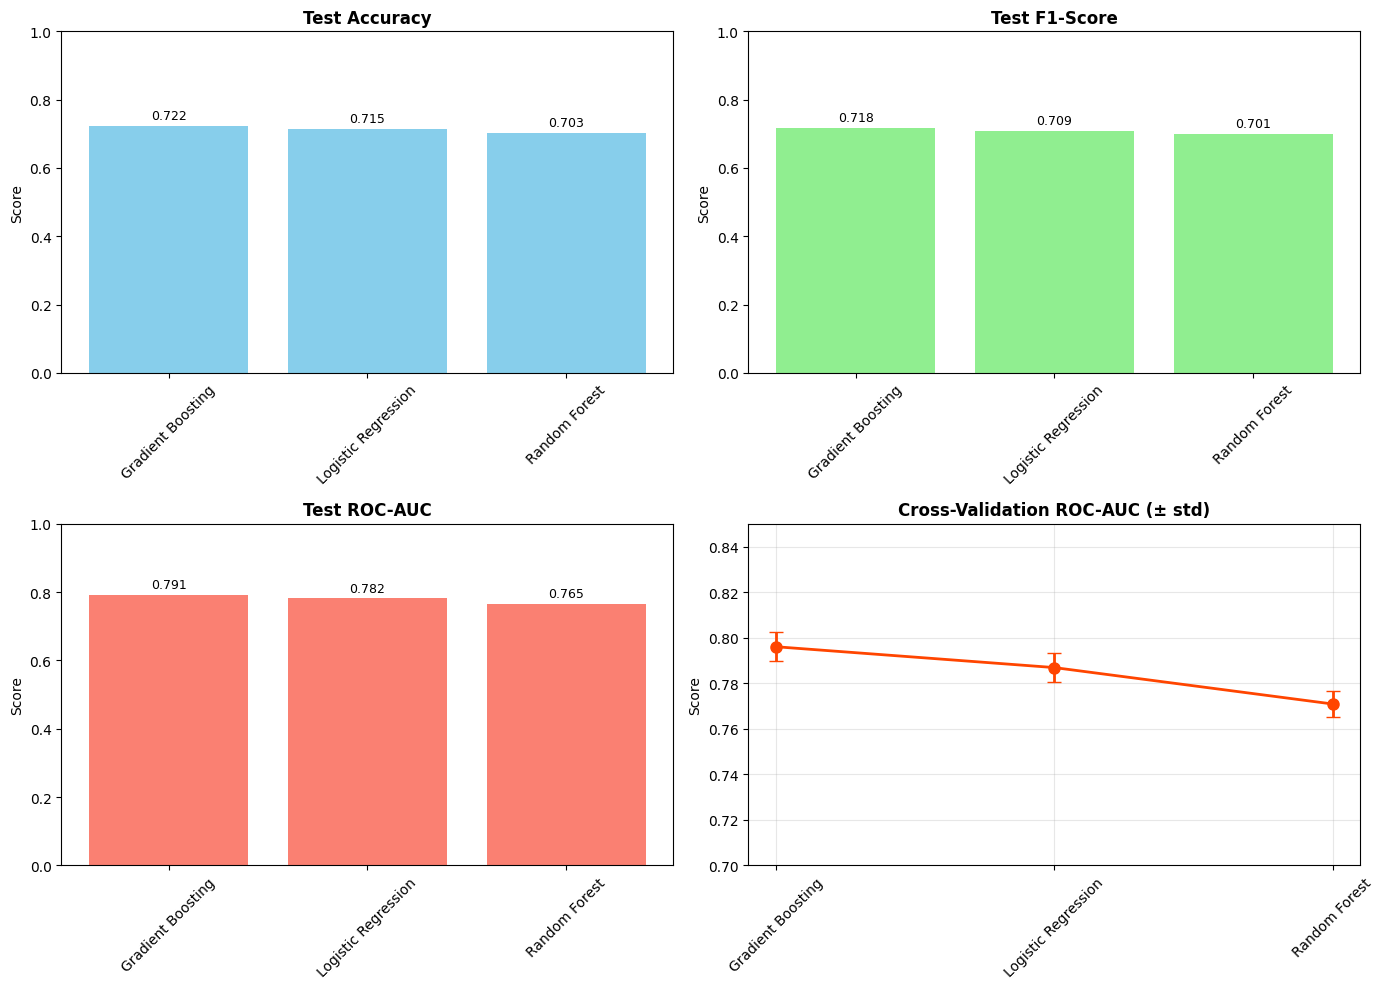

✓ Visualizations affichées


In [25]:
# Visualiser les performances des modèles
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].bar(comparison_df['Modèle'], comparison_df['Test Accuracy'], color='skyblue')
axes[0, 0].set_title('Test Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Test Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# F1-Score
axes[0, 1].bar(comparison_df['Modèle'], comparison_df['Test F1'], color='lightgreen')
axes[0, 1].set_title('Test F1-Score', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Test F1']):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# ROC-AUC
axes[1, 0].bar(comparison_df['Modèle'], comparison_df['Test ROC-AUC'], color='salmon')
axes[1, 0].set_title('Test ROC-AUC', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Test ROC-AUC']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# CV ROC-AUC avec erreurs
axes[1, 1].errorbar(
    range(len(comparison_df)), 
    comparison_df['CV ROC-AUC'], 
    yerr=[results[m]['cv_roc_auc_std'] for m in comparison_df['Modèle']],
    fmt='o-', color='orangered', capsize=5, markersize=8, linewidth=2
)
axes[1, 1].set_title('Cross-Validation ROC-AUC (± std)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0.7, 0.85)
axes[1, 1].set_xticks(range(len(comparison_df)))
axes[1, 1].set_xticklabels(comparison_df['Modèle'], rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizations affichées")

ANALYSE DÉTAILLÉE - Gradient Boosting

Matrice de Confusion:
[[5172 1832]
 [2057 4939]]

Rapport de Classification:
                precision    recall  f1-score   support

Pas Malade (0)       0.72      0.74      0.73      7004
    Malade (1)       0.73      0.71      0.72      6996

      accuracy                           0.72     14000
     macro avg       0.72      0.72      0.72     14000
  weighted avg       0.72      0.72      0.72     14000



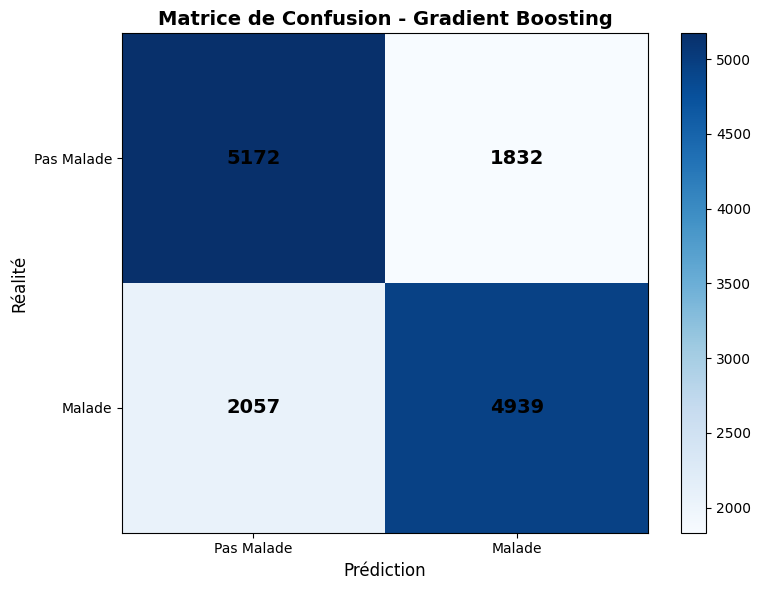


✓ Matrice de confusion affichée


In [26]:
# Analyser le meilleur modèle en détail
print("="*60)
print(f"ANALYSE DÉTAILLÉE - {best_model_name}")
print("="*60)

# Matrice de confusion
cm = confusion_matrix(y_test, best_model_data['y_pred'])

print("\nMatrice de Confusion:")
print(cm)

# Rapport de classification
print(f"\nRapport de Classification:")
print(classification_report(y_test, best_model_data['y_pred'], 
                          target_names=['Pas Malade (0)', 'Malade (1)']))

# Visualiser la matrice de confusion
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

ax.set_xlabel('Prédiction', fontsize=12)
ax.set_ylabel('Réalité', fontsize=12)
ax.set_title(f'Matrice de Confusion - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pas Malade', 'Malade'])
ax.set_yticklabels(['Pas Malade', 'Malade'])

# Ajouter les valeurs
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", 
                      color="black", fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\n✓ Matrice de confusion affichée")

COURBES ROC - COMPARAISON DE TOUS LES MODÈLES


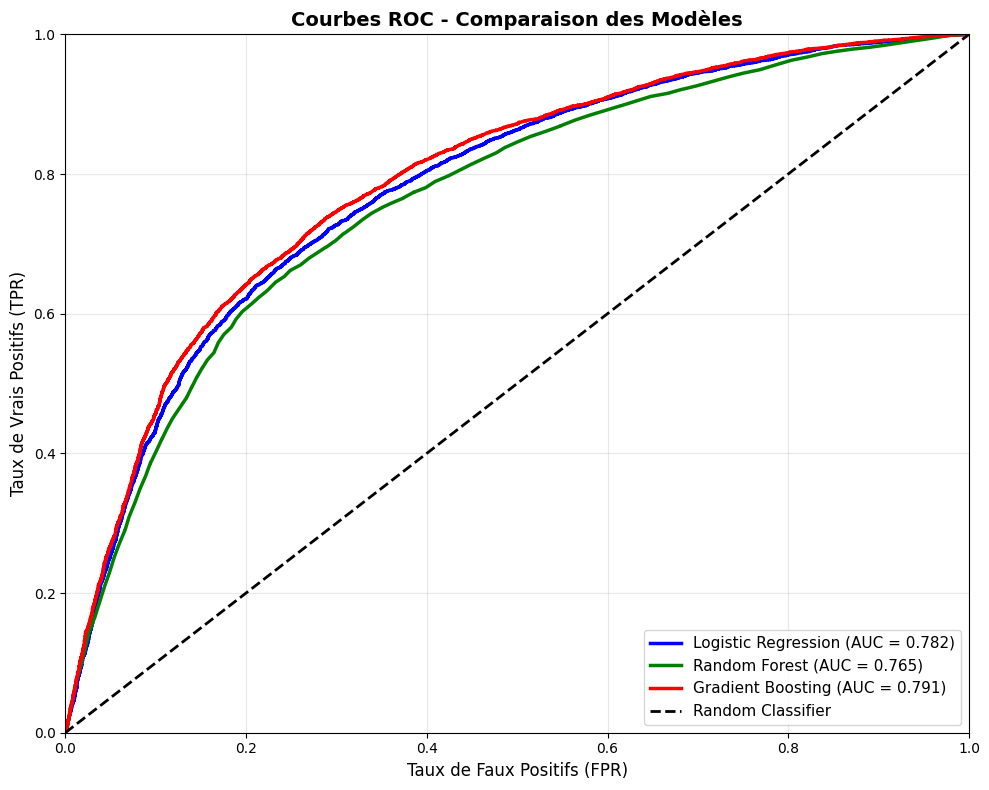


✓ Courbes ROC affichées


In [27]:
# Tracer les courbes ROC pour tous les modèles
from sklearn.metrics import roc_curve, auc

print("="*60)
print("COURBES ROC - COMPARAISON DE TOUS LES MODÈLES")
print("="*60)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['blue', 'green', 'red', 'orange']

for i, (model_name, result) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', 
            linewidth=2.5, color=colors[i])

# Ligne de base (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)

ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\n✓ Courbes ROC affichées")

IMPORTANCE DES FEATURES - Gradient Boosting

Top 10 Features:
              Feature  Importance
   hypertension_stage    0.325878
       pulse_pressure    0.238411
    cardio_risk_score    0.186185
age_ap_hi_interaction    0.160270
  imc_age_interaction    0.034858
        tension_ratio    0.010568
                  age    0.007788
     weight_age_ratio    0.007474
                  imc    0.007171
          cholesterol    0.006432


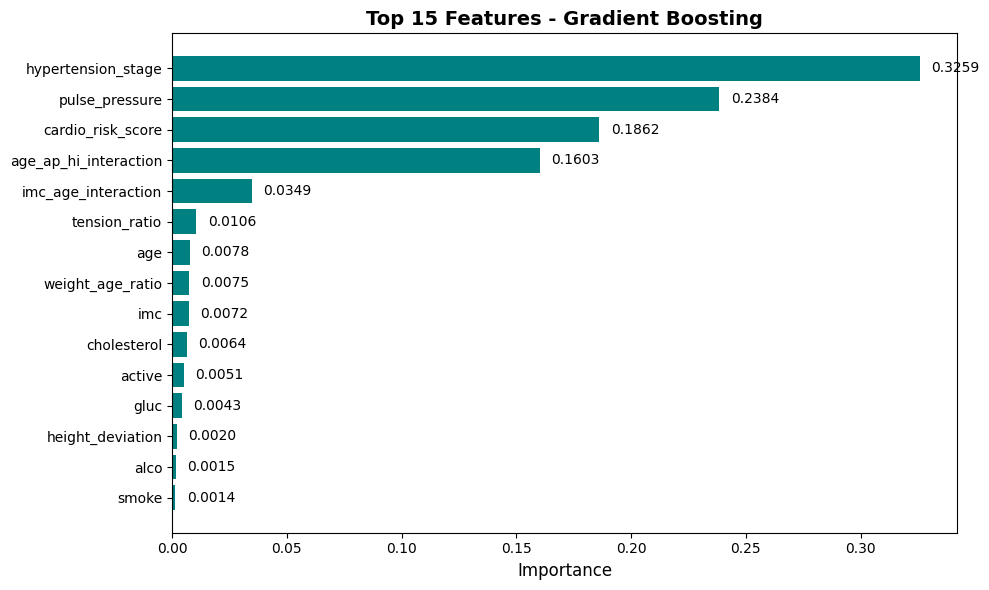


✓ Importance des features affichée


In [ ]:
# Afficher l'importance des features du meilleur modèle
print("="*60)
print(f"IMPORTANCE DES FEATURES - {best_model_name}")
print("="*60)

# Vérifier si le modèle a l'attribut feature_importances_
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 Features:")
    print(feature_importance.head(10).to_string(index=False))
    
    # Visualiser
    fig, ax = plt.subplots(figsize=(10, 6))
    top_features = feature_importance.head(15)
    ax.barh(range(len(top_features)), top_features['Importance'], color='teal')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'])
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top 15 Features - {best_model_name}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    for i, v in enumerate(top_features['Importance']):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Importance des features affichée")
else:
    print(f"\n{best_model_name} ne dispose pas d'un attribut 'feature_importances_'")
    
    # Pour logistic regression, afficher les coefficients
    if hasattr(best_model, 'coef_'):
        coef_importance = pd.DataFrame({
            'Feature': X_train.columns,
            'Coefficient': best_model.coef_[0]
        }).reindex(pd.DataFrame({
            'Feature': X_train.columns,
            'Abs_Coefficient': np.abs(best_model.coef_[0])
        }).sort_values('Abs_Coefficient', ascending=False)['Feature'])
        
        print("\nTop 10 Features (par valeur absolue du coefficient):")
        print(coef_importance.head(10).to_string(index=False))

In [ ]:
print("="*60)
print("OPTIMISATION DU SEUIL DE CLASSIFICATION")
print("="*60)

# Utiliser les données appropriées selon le modèle
X_test_data = X_test_scaled if best_model_scaled else X_test

# Extraire les probabilités
y_probs = best_model.predict_proba(X_test_data)[:, 1]

print(f"\n Distribution des probabilités prédites:")
print(f"   Min: {y_probs.min():.4f}")
print(f"   Max: {y_probs.max():.4f}")
print(f"   Moyenne: {y_probs.mean():.4f}")
print(f"   Médiane: {np.median(y_probs):.4f}")

# Seuil par défaut (0.50)
print(f"\n{'─'*60}")
print(" SEUIL PAR DÉFAUT (0.50)")
print(f"{'─'*60}")
y_pred_default = (y_probs >= 0.50).astype(int)
print(classification_report(y_test, y_pred_default, 
                          target_names=['Pas Malade (0)', 'Malade (1)']))


OPTIMISATION DU SEUIL DE CLASSIFICATION

📊 Distribution des probabilités prédites:
   Min: 0.0329
   Max: 0.9284
   Moyenne: 0.5011
   Médiane: 0.4830

────────────────────────────────────────────────────────────
 SEUIL PAR DÉFAUT (0.50)
────────────────────────────────────────────────────────────
                precision    recall  f1-score   support

Pas Malade (0)       0.72      0.74      0.73      7004
    Malade (1)       0.73      0.71      0.72      6996

      accuracy                           0.72     14000
     macro avg       0.72      0.72      0.72     14000
  weighted avg       0.72      0.72      0.72     14000



In [30]:

# Seuil réduit (0.35)
print(f"\n{'─'*60}")
print(" SEUIL RÉDUIT (0.35) - Plus sensible")
print(f"{'─'*60}")
y_pred_sensitive = (y_probs >= 0.35).astype(int)
print(classification_report(y_test, y_pred_sensitive, 
                          target_names=['Pas Malade (0)', 'Malade (1)']))




────────────────────────────────────────────────────────────
 SEUIL RÉDUIT (0.35) - Plus sensible
────────────────────────────────────────────────────────────
                precision    recall  f1-score   support

Pas Malade (0)       0.78      0.56      0.65      7004
    Malade (1)       0.66      0.84      0.74      6996

      accuracy                           0.70     14000
     macro avg       0.72      0.70      0.69     14000
  weighted avg       0.72      0.70      0.69     14000




────────────────────────────────────────────────────────────
📈 COMPARAISON DES MATRICES DE CONFUSION
────────────────────────────────────────────────────────────

Seuil 0.50:
  TN=5172, FP=1832
  FN=2057, TP=4939

Seuil 0.35:
  TN=3907, FP=3097
  FN=1087, TP=5909


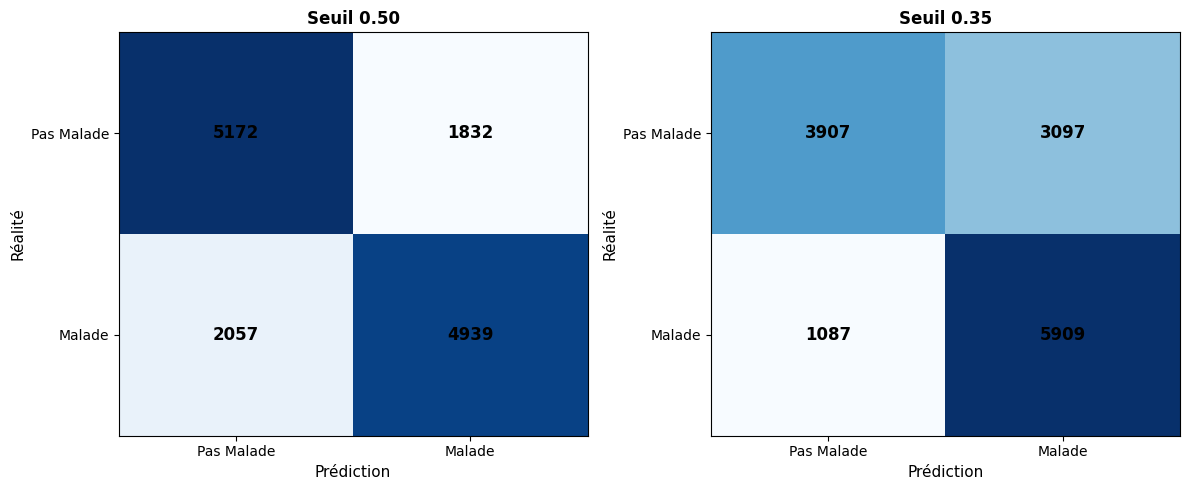

In [31]:
# Comparer les matrices de confusion
cm_default = confusion_matrix(y_test, y_pred_default)
cm_sensitive = confusion_matrix(y_test, y_pred_sensitive)

print(f"\n{'─'*60}")
print("📈 COMPARAISON DES MATRICES DE CONFUSION")
print(f"{'─'*60}")
print(f"\nSeuil 0.50:")
print(f"  TN={cm_default[0,0]}, FP={cm_default[0,1]}")
print(f"  FN={cm_default[1,0]}, TP={cm_default[1,1]}")

print(f"\nSeuil 0.35:")
print(f"  TN={cm_sensitive[0,0]}, FP={cm_sensitive[0,1]}")
print(f"  FN={cm_sensitive[1,0]}, TP={cm_sensitive[1,1]}")

# Visualiser la comparaison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in [(axes[0], cm_default, 'Seuil 0.50'), 
                       (axes[1], cm_sensitive, 'Seuil 0.35')]:
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xlabel('Prédiction', fontsize=11)
    ax.set_ylabel('Réalité', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pas Malade', 'Malade'])
    ax.set_yticklabels(['Pas Malade', 'Malade'])
    
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, cm[i, j], ha="center", va="center", 
                          color="black", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)

In [ ]:
print("\n" + "="*60)
print("RECOMMANDATIONS D'OPTIMISATION BASÉES SUR LES RÉSULTATS")
print("="*60)

# Analyser la performance
best_roc = comparison_df.iloc[0]['Test ROC-AUC']
best_f1 = comparison_df.iloc[0]['Test F1']

print(f"\n PERFORMANCE ACTUELLE:")
print(f"   Meilleur modèle: {best_model_name}")
print(f"   ROC-AUC: {best_roc:.4f}")
print(f"   F1-Score: {best_f1:.4f}")

recommendations = []

# Recommandation 1: Équilibre des classes
if imbalance_ratio > 1.5:
    recommendations.append({
        'priority': '🔴 CRITIQUE',
        'issue': 'Déséquilibre des classes',
        'ratio': f'{imbalance_ratio:.1f}:1',
        'solution': 'Utiliser class_weight="balanced" dans les modèles ou SMOTE',
        'impact': 'Peut améliorer recall de 5-15%'
    })

# Recommandation 2: Hyperparamètre tuning
cv_std = comparison_df.iloc[0]['CV ROC-AUC'] * 0.02  # Estimation de std
if best_roc < 0.80:
    recommendations.append({
        'priority': '🟠 HAUTE',
        'issue': 'ROC-AUC < 0.80 - marge d\'amélioration',
        'score': f'{best_roc:.4f}',
        'solution': 'GridSearchCV/RandomizedSearchCV pour tuning d\'hyperparamètres',
        'impact': 'ROC-AUC potentiel: +0.02 à +0.05'
    })

# Recommandation 3: Feature Engineering
if len(weak_features) > 3:
    recommendations.append({
        'priority': '🟠 HAUTE',
        'issue': f'{len(weak_features)} features faiblement corrélées',
        'solution': 'Créer features d\'interaction: tension_ratio, imc*age, pulse_pressure',
        'impact': 'Peut améliorer ROC-AUC de 1-3%'
    })

# Recommandation 4: Feature Selection
if X.shape[1] > 15:
    recommendations.append({
        'priority': '🟡 MOYENNE',
        'issue': f'Beaucoup de features ({X.shape[1]})',
        'solution': 'SelectKBest ou RFE pour réduire la dimension',
        'impact': 'Meilleure généralisation, temps d\'entraînement réduit'
    })

# Recommandation 5: Ensemble Methods
recommendations.append({
    'priority': '🟡 MOYENNE',
    'issue': 'Potentiel d\'amélioration via ensemble',
    'solution': 'VotingClassifier ou Stacking (LR + RF + GB)',
    'impact': 'ROC-AUC potentiel: +1 à +3%'
})

# Recommandation 6: Distribution asymétrique
if len(skewed_features) > 0:
    recommendations.append({
        'priority': '🟡 MOYENNE',
        'issue': f'{len(skewed_features)} features asymétriques',
        'features': ', '.join(skewed_features.index.tolist()[:3]),
        'solution': 'Log-transform ou Box-Cox sur features asymétriques',
        'impact': 'Améliore la stabilité des modèles linéaires'
    })

# Afficher les recommandations
for i, rec in enumerate(recommendations, 1):
    print(f"\n{'─'*60}")
    print(f"Recommandation {i}: {rec['priority']}")
    print(f"{'─'*60}")
    for key, value in rec.items():
        if key != 'priority':
            print(f"{key.replace('_', ' ').title():.<20} {value}")

print("\n" + "="*60)
print("ORDRE DE PRIORITÉ SUGGÉRÉ:")
print("="*60)
print(" Si déséquilibre: Ajouter class_weight='balanced' (5 min)")
print("2️⃣  Feature Engineering: Créer tension_ratio, pulse_pressure (10 min)")
print("3️⃣  GridSearchCV: Tuner hyperparamètres Random Forest (15-20 min)")
print("4️⃣  VotingClassifier: Combiner 2-3 modèles (5 min)")
print("5️⃣  Feature Selection: RFE ou SelectKBest (10 min)")
print("="*60)


RECOMMANDATIONS D'OPTIMISATION BASÉES SUR LES RÉSULTATS

📊 PERFORMANCE ACTUELLE:
   Meilleur modèle: Gradient Boosting
   ROC-AUC: 0.7910
   F1-Score: 0.7175

────────────────────────────────────────────────────────────
Recommandation 1: 🟠 HAUTE
────────────────────────────────────────────────────────────
Issue............... ROC-AUC < 0.80 - marge d'amélioration
Score............... 0.7910
Solution............ GridSearchCV/RandomizedSearchCV pour tuning d'hyperparamètres
Impact.............. ROC-AUC potentiel: +0.02 à +0.05

────────────────────────────────────────────────────────────
Recommandation 2: 🟠 HAUTE
────────────────────────────────────────────────────────────
Issue............... 7 features faiblement corrélées
Solution............ Créer features d'interaction: tension_ratio, imc*age, pulse_pressure
Impact.............. Peut améliorer ROC-AUC de 1-3%

────────────────────────────────────────────────────────────
Recommandation 3: 🟡 MOYENNE
──────────────────────────────────